# Homework 2 Task 1

## Choosing three sections 

For this assignment I will be adressing: 

-  Non-linearity of the response-predictor relationships
-  Correlation of error terms
-  High-leverage points

a short paragraph explaining what the problem is, why it matters, and how to detect it (and how to address it, if applicable)
a question that came up while reading that you couldn’t answer from the text alone, and the answer you investigated


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


## Non-linearity
In a perfect world every relationship would be linear, however especially in biological sciences it is often not the case. If we are assuming a linear model on data which is inherintly not linear, then all conclusions will be incorrect. To detect non-linearity in data you can plot residuals of the model ei = yi − yˆi, versus the predictor xi. If the plot produces a clear linear relationship, then all is good. However if the plot produces some other shape then there is likely non-linearity. To fix this you would fit some other model. One question I had when originally reading this was: how do you choose the right transformation? In further investigation I found that the shape of the residual plot can also be good to show which transformation to use. Below shows a plot (generated by ai) of the issue and how it can be fixed. 

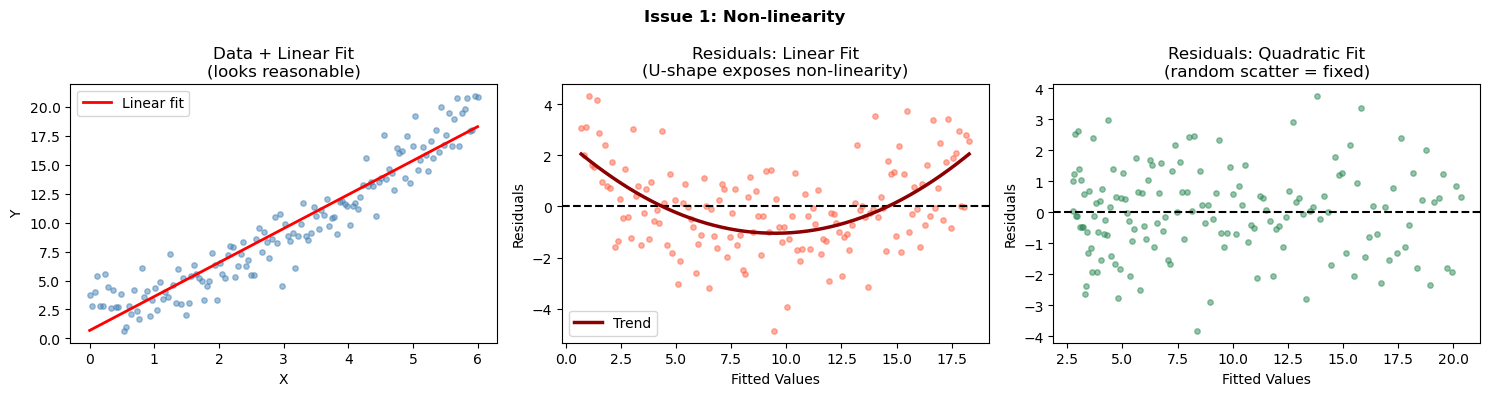

In [24]:
np.random.seed(42)
n = 150
x = np.linspace(0, 6, n)
y = 3 + 0.8 * x + 0.35 * x**2 + np.random.normal(0, 1.5, n)

lin_model = LinearRegression().fit(x.reshape(-1, 1), y)
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_model.fit(x.reshape(-1, 1), y)

resid_lin  = y - lin_model.predict(x.reshape(-1, 1))
resid_poly = y - poly_model.predict(x.reshape(-1, 1))

fitted_lin = lin_model.predict(x.reshape(-1, 1))
smooth_order = np.argsort(fitted_lin)
smooth_x = fitted_lin[smooth_order]
smooth_y = resid_lin[smooth_order]
loess_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
loess_model.fit(smooth_x.reshape(-1, 1), smooth_y)
trend_line = loess_model.predict(smooth_x.reshape(-1, 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x, y, alpha=0.5, s=15, color='steelblue')
axes[0].plot(x, lin_model.predict(x.reshape(-1, 1)), 'r-', lw=2, label='Linear fit')
axes[0].set_title('Data + Linear Fit\n(looks reasonable)')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y'); axes[0].legend()

axes[1].scatter(fitted_lin, resid_lin, alpha=0.5, s=15, color='tomato')
axes[1].axhline(0, color='k', lw=1.5, ls='--')
axes[1].plot(smooth_x, trend_line, color='darkred', lw=2.5, label='Trend')
axes[1].set_title('Residuals: Linear Fit\n(U-shape exposes non-linearity)')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals'); axes[1].legend()

axes[2].scatter(poly_model.predict(x.reshape(-1, 1)), resid_poly, alpha=0.5, s=15, color='seagreen')
axes[2].axhline(0, color='k', lw=1.5, ls='--')
axes[2].set_title('Residuals: Quadratic Fit\n(random scatter = fixed)')
axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('Residuals')

plt.suptitle('Issue 1: Non-linearity', fontweight='bold')
plt.tight_layout()
plt.show()

In these plots we see what appears at first as fitting a linear distribution. When we plot the residuals of the linear model, however, we see a U shape trend. This suggests non linearity in the data. The third plot shows the residuals with a quadratic model instead which have no trend, indicating a better fitting model. 

## Correlation of error terms
This issue is pervasive in our capstone dataset. What happens is there is a correlation within error terms, which can shrink our standard errors and our 95% confidence intervals (*this is how we originally diagnosed this in the capstone*). Additionally the p-values will also be lower for affected models. There are many tests to diagnose this, but a surefire test is plotting your residuals over time. If there is a trend, with residuals being closely related, it's quite likely that there is some correlation of your error terms. One question I had while reading this is how to plot the residuals when time is not available. The answer, upon further research, is to use the index value instead of time to get sequential residuals. Solutions to this include sampling and adding random effects to your model. An ai generated plot to display this issue is below. 

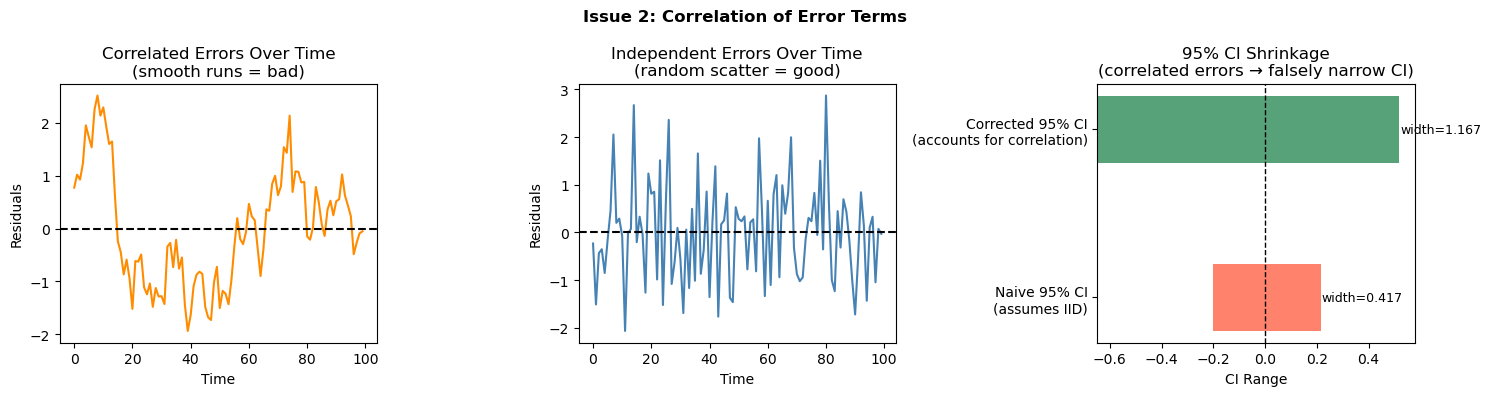

In [25]:
np.random.seed(42)
n = 100
t = np.arange(n)

phi = 0.92
eps_corr = np.zeros(n)
for i in range(1, n):
    eps_corr[i] = phi * eps_corr[i-1] + np.random.normal(0, 0.5)

eps_iid = np.random.normal(0, np.std(eps_corr), n)
y_corr = 0.3 * t + eps_corr
y_iid  = 0.3 * t + eps_iid

def get_resid(y, t):
    m = LinearRegression().fit(t.reshape(-1, 1), y)
    return y - m.predict(t.reshape(-1, 1))

resid_corr = get_resid(y_corr, t)
resid_iid  = get_resid(y_iid,  t)

# CI shrinkage: bootstrap CIs assuming IID vs block bootstrap for correlated
def bootstrap_ci(resid, n_boot=1000, block=False, block_size=10):
    means = []
    for _ in range(n_boot):
        if block:
            starts = np.random.randint(0, len(resid) - block_size, len(resid) // block_size)
            sample = np.concatenate([resid[s:s+block_size] for s in starts])
        else:
            sample = np.random.choice(resid, size=len(resid), replace=True)
        means.append(np.mean(sample))
    return np.percentile(means, [2.5, 97.5])

ci_naive  = bootstrap_ci(resid_corr, block=False)  # ignores correlation
ci_correct = bootstrap_ci(resid_corr, block=True)   # accounts for correlation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Correlated residuals
axes[0].plot(t, resid_corr, color='darkorange', lw=1.5)
axes[0].axhline(0, color='k', lw=1.5, ls='--')
axes[0].set_title('Correlated Errors Over Time\n(smooth runs = bad)')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Residuals')

# Plot 2: IID residuals
axes[1].plot(t, resid_iid, color='steelblue', lw=1.5)
axes[1].axhline(0, color='k', lw=1.5, ls='--')
axes[1].set_title('Independent Errors Over Time\n(random scatter = good)')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('Residuals')

# Plot 3: CI shrinkage
labels = ['Naive 95% CI\n(assumes IID)', 'Corrected 95% CI\n(accounts for correlation)']
cis = [ci_naive, ci_correct]
colors = ['tomato', 'seagreen']
for i, (ci, label, color) in enumerate(zip(cis, labels, colors)):
    axes[2].barh(i, ci[1] - ci[0], left=ci[0], height=0.4, color=color, alpha=0.8)
    axes[2].text(ci[1] + 0.002, i, f'width={ci[1]-ci[0]:.3f}', va='center', fontsize=9)

axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(labels)
axes[2].axvline(0, color='k', lw=1, ls='--')
axes[2].set_title('95% CI Shrinkage\n(correlated errors → falsely narrow CI)')
axes[2].set_xlabel('CI Range')

plt.suptitle('Issue 2: Correlation of Error Terms', fontweight='bold')
plt.tight_layout()
plt.show()

These plots show what correlated and non correlated errors look like when plotted as well as the effect to the confidence intervals. The first plot is a classic example of correlated errors over time, with smooth lines indicating some correlation. This is contrasted by the second plot with a random scatter. The last plot shows what the effect of the width of confidence intervals can look like with correlated errors, and after they are fixed. 

## High leaverage points
High leaverage points are points which 'pull' on your model due to unusual points in x_i. High leaverage points tend to have a large effect on the estimated regression line. For single predictor regression high leaverage points are easy to identify by looking at the plot. In a multiple predictor regression it is harder to spot, so you use the formula: $$h_i = \frac{1}{n} + \frac{(x_i - \bar{x})^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$ To fix high leaverage points you remove them from the equation and reassess. One question I had about high leaverage points was: how do you go about fixing this when you have a large number of disconnected high leaverage points? I found when researching that instead of dropping them you must assess your model and its possible in this case that the model itself is the issue. Below is an ai generated plot displaying high leaverage points. 

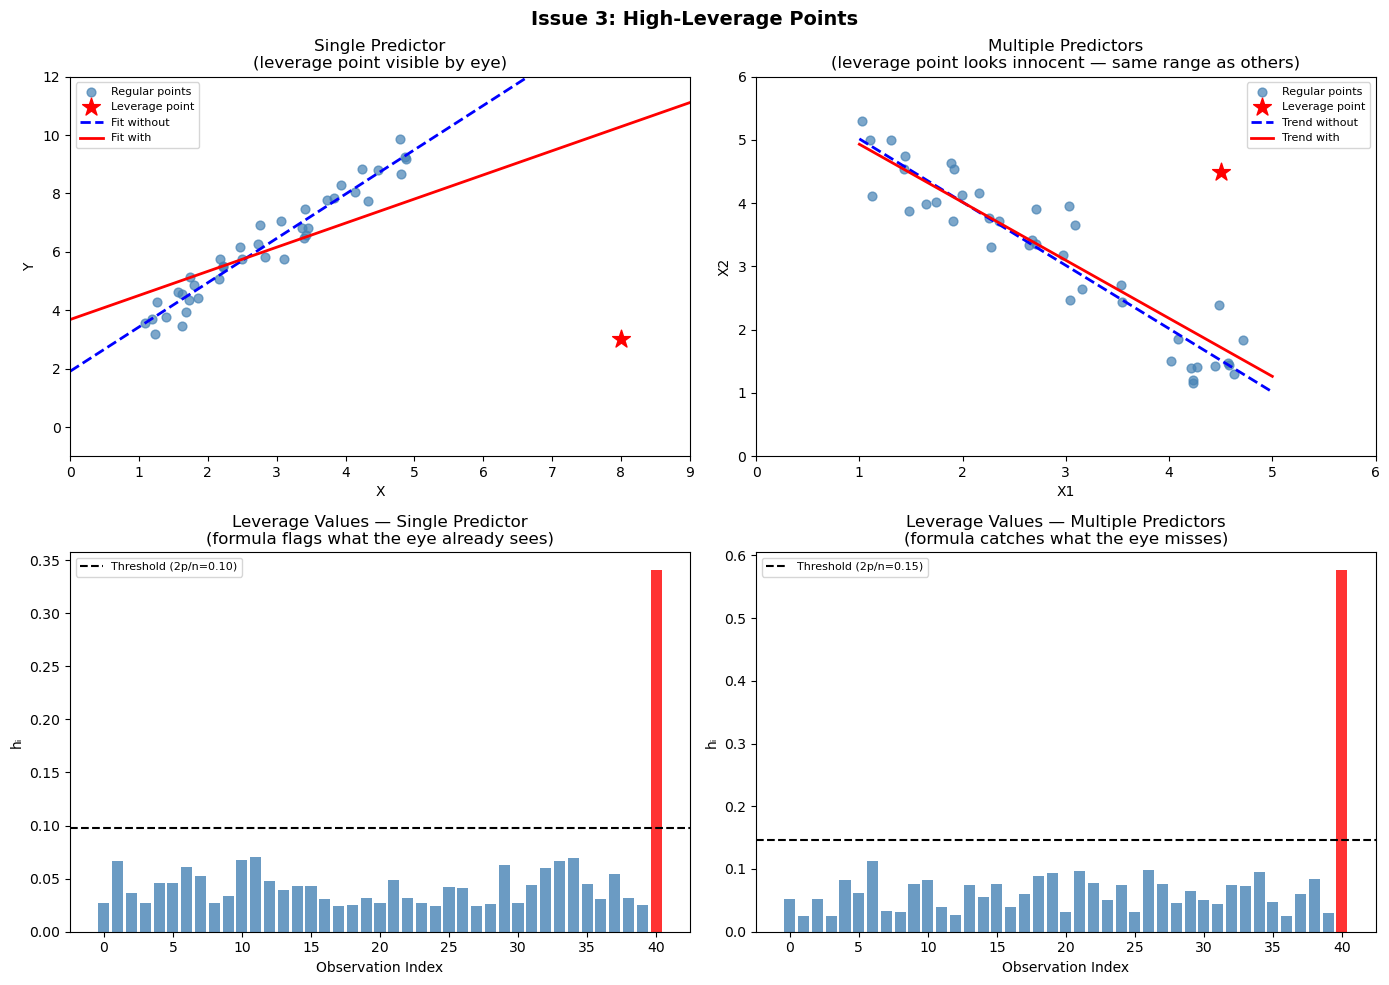

In [26]:
np.random.seed(42)

# --- Single predictor data ---
n = 40
x_base = np.random.uniform(1, 5, n)
y_base = 2 + 1.5 * x_base + np.random.normal(0, 0.5, n)
x_lev = np.append(x_base, 8)
y_lev = np.append(y_base, 3)

model_without = LinearRegression().fit(x_base.reshape(-1, 1), y_base)
model_with    = LinearRegression().fit(x_lev.reshape(-1, 1), y_lev)

x_bar = np.mean(x_lev)
h_single = 1/len(x_lev) + (x_lev - x_bar)**2 / np.sum((x_lev - x_bar)**2)
threshold_single = 2 * 2 / len(x_lev)

# --- Multiple predictor data ---
# x1 and x2 are negatively correlated — high x1 goes with low x2
n2 = 40
x1 = np.random.uniform(1, 5, n2)
x2 = 6 - x1 + np.random.normal(0, 0.4, n2)  # negative relationship
y2 = 2 + 1.5 * x1 + 0.8 * x2 + np.random.normal(0, 0.5, n2)

# Leverage point: x1=4.5, x2=4.5 — both within normal range individually
# but unusual combination (high x1 AND high x2 never occurs in the data)
x1_lev = np.append(x1, 4.5)
x2_lev = np.append(x2, 4.5)
y2_lev = np.append(y2, 5)

X2 = np.column_stack([np.ones(len(x1_lev)), x1_lev, x2_lev])
H2 = X2 @ np.linalg.inv(X2.T @ X2) @ X2.T
h_multi = np.diag(H2)
threshold_multi = 2 * 3 / len(x1_lev)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Single predictor ---
x_plot = np.linspace(0, 9, 200)
axes[0, 0].scatter(x_base, y_base, color='steelblue', s=40, alpha=0.7, label='Regular points')
axes[0, 0].scatter(8, 3, color='red', s=180, zorder=5, marker='*', label='Leverage point')
axes[0, 0].plot(x_plot, model_without.predict(x_plot.reshape(-1, 1)), 'b--', lw=2, label='Fit without')
axes[0, 0].plot(x_plot, model_with.predict(x_plot.reshape(-1, 1)),    'r-',  lw=2, label='Fit with')
axes[0, 0].set_xlim(0, 9); axes[0, 0].set_ylim(-1, 12)
axes[0, 0].set_title('Single Predictor\n(leverage point visible by eye)')
axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('Y')
axes[0, 0].legend(fontsize=8)

# --- Plot 2: Multiple predictors ---
# Leverage point sits in normal range of both axes but breaks the x1/x2 pattern
x1_sorted = np.linspace(1, 5, 200)
trend_without = np.poly1d(np.polyfit(x1, x2, 1))
trend_with    = np.poly1d(np.polyfit(x1_lev, x2_lev, 1))

axes[0, 1].scatter(x1, x2, color='steelblue', s=40, alpha=0.7, label='Regular points')
axes[0, 1].scatter(4.5, 4.5, color='red', s=180, zorder=5, marker='*', label='Leverage point')
axes[0, 1].plot(x1_sorted, trend_without(x1_sorted), 'b--', lw=2, label='Trend without')
axes[0, 1].plot(x1_sorted, trend_with(x1_sorted),    'r-',  lw=2, label='Trend with')
axes[0, 1].set_xlim(0, 6); axes[0, 1].set_ylim(0, 6)
axes[0, 1].set_title('Multiple Predictors\n(leverage point looks innocent — same range as others)')
axes[0, 1].set_xlabel('X1'); axes[0, 1].set_ylabel('X2')
axes[0, 1].legend(fontsize=8)

# --- Plot 3: Leverage bar chart — single predictor ---
colors_s = ['red' if h > threshold_single else 'steelblue' for h in h_single]
axes[1, 0].bar(range(len(h_single)), h_single, color=colors_s, alpha=0.8)
axes[1, 0].axhline(threshold_single, color='k', ls='--', lw=1.5, label=f'Threshold (2p/n={threshold_single:.2f})')
axes[1, 0].set_title('Leverage Values — Single Predictor\n(formula flags what the eye already sees)')
axes[1, 0].set_xlabel('Observation Index'); axes[1, 0].set_ylabel('hᵢ')
axes[1, 0].legend(fontsize=8)

# --- Plot 4: Leverage bar chart — multiple predictors ---
colors_m = ['red' if h > threshold_multi else 'steelblue' for h in h_multi]
axes[1, 1].bar(range(len(h_multi)), h_multi, color=colors_m, alpha=0.8)
axes[1, 1].axhline(threshold_multi, color='k', ls='--', lw=1.5, label=f'Threshold (2p/n={threshold_multi:.2f})')
axes[1, 1].set_title('Leverage Values — Multiple Predictors\n(formula catches what the eye misses)')
axes[1, 1].set_xlabel('Observation Index'); axes[1, 1].set_ylabel('hᵢ')
axes[1, 1].legend(fontsize=8)

plt.suptitle('Issue 3: High-Leverage Points', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In these plots we see the effects of high leaverage points on single predictor as well as multiple predictors. In single predictor, high leaverage point is easily identified visually as it is outside the normal range of x. This is backed up in the plot of the leaverage plot. In the multiple predictor plot we can see that the high leaverage point is within the normal range of x. It could be seen as normal, until we look at the leaverage plot and see a high leaverage point. 

### Analysis of AI
To complete these plot I used claude ai. The first two plots were much more simple, and took ~ 3 prompts each to get to a point that I wanted them to be at. These secondary prompts were mostly aesthetic, such as adding a trend line and updating the plots to reflect my interpretations. The third plot was much more difficult to get to a good point. It required around 5 prompts to get to this point. At one point claude completely lost a prompt I had previously generated which had generated a similar plot. I also had to make clear to claude the effect of multiple predictors because it seemed confused. It also kept including multiple high leaverage points when I had asked for a single in each. Overall I would say high leaverage points are the most 'abstract' topic that was covered, so it makes sense that between my explination and the general obscurity it had trouble. I just had to get very explicit to get it working. 